In [26]:
%matplotlib inline

In [1]:
import pandas as pd

In [2]:
P_I=pd.read_csv('insurance_claims.csv')
P_I.head(2)

,claim_id,patient_id,claim_date,diagnosis_code,diagnosis_description,claim_type,provider_npi,billed_amount,claim_status,approved_amount,payer
0,CLM500000,PT100636,2024-04-20,I25.10,Coronary artery disease,Prescription,1000000079,59.13,Approved,53.95,Aetna
1,CLM500001,PT100923,2023-07-17,M54.5,Low back pain,Lab Work,1000000105,67.59,Approved,67.22,Medicare


In [4]:
from quick_profile import generate_report

In [5]:
generate_report(P_I, output_file="P_I_report.html", title="Dataset Report")

Report saved to P_I_report.html


In [6]:
P_I.describe()

,provider_npi,billed_amount,approved_amount
count,3.000000e+03,3000.000000,2760.000000
mean,1.000000e+09,1243.797280,928.881862
std,5.729457e+01,3350.236963,2769.819977
min,1.000000e+09,20.000000,0.000000
25%,1.000000e+09,102.537500,58.467500
50%,1.000000e+09,201.400000,137.415000
75%,1.000000e+09,625.335000,367.320000
max,1.000000e+09,29335.790000,27228.680000


###  Feature scaling

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
P_I.sample(5)

,claim_id,patient_id,claim_date,diagnosis_code,diagnosis_description,claim_type,provider_npi,billed_amount,claim_status,approved_amount,payer
2634,CLM502634,PT100147,2024-08-15,M54.5,Low back pain,Emergency Room,1000000186,1541.86,Denied,0.00,Medicaid
329,CLM500329,PT100897,2024-11-19,J45.909,"Asthma, unspecified",Physical Therapy,1000000167,136.13,Approved,121.76,Cigna
1446,CLM501446,PT100156,2024-01-05,E78.5,Hyperlipidemia,Physical Therapy,1000000083,155.15,Approved,142.90,BlueCross BlueShield
648,CLM500648,PT100751,2023-01-29,J45.909,"Asthma, unspecified",Prescription,1000000082,63.99,Approved,58.87,Medicaid
2741,CLM502741,PT100402,2025-08-04,I25.10,Coronary artery disease,Specialist Consultation,1000000147,361.65,Approved,351.11,BlueCross BlueShield


In [9]:
P_I.shape

(3000, 11)

In [10]:
P_I.isnull().sum()

claim_id                   0
patient_id                 0
claim_date                 0
diagnosis_code             0
diagnosis_description      0
claim_type                 0
provider_npi               0
billed_amount              0
claim_status               0
approved_amount          240
payer                      0
dtype: int64

In [11]:
P_I.dropna(inplace=True)

In [12]:
X=P_I[['billed_amount', 'approved_amount']]
X

,billed_amount,approved_amount
0,59.13,53.95
1,67.59,67.22
3,2557.82,2188.41
4,7707.24,6572.36
5,43.31,42.64
...,...,...
2994,124.34,107.55
2995,14316.32,12628.64
2996,327.97,283.83
2997,50.27,49.72


In [13]:
P_I['claim_status'].unique()

<StringArray>
['Approved', 'Denied', 'Partially Approved']
Length: 3, dtype: str

In [15]:
P_int=P_I['payer']
P_int
payer_map= {'Aetna':1, 'Medicare':2, 'Medicaid':3, 'Cigna':4, 'UnitedHealthcare':5, 'BlueCross BlueShield':6}
Y=P_int.map(payer_map).astype(int)
Y

0       1
1       2
3       3
4       4
5       5
       ..
2994    5
2995    4
2996    3
2997    2
2998    1
Name: payer, Length: 2760, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2)
X_train, X_test, Y_train, Y_test

(      billed_amount  approved_amount
 254           62.10             0.00
 2296          93.45            80.09
 1219          50.19            46.68
 1847        1604.33          1556.13
 2901       10070.55             0.00
 ...             ...              ...
 1082         146.72           139.28
 2900         254.23           175.41
 897         1489.57          1385.18
 2820          76.00            70.13
 2490         106.09           103.84
 
 [2208 rows x 2 columns],
       billed_amount  approved_amount
 2456       15007.57             0.00
 2049         215.29           189.84
 2004         114.43           112.37
 1392         291.45           289.96
 2158         135.56           133.63
 ...             ...              ...
 602          230.56           217.08
 563           79.05            71.72
 437          249.19           236.44
 2318         191.26           180.03
 2599         738.03           658.84
 
 [552 rows x 2 columns],
 254     2
 2296    1
 1219    3


In [17]:
X_train.describe()

,billed_amount,approved_amount
count,2208.000000,2208.000000
mean,1244.737283,923.440240
std,3372.098755,2762.290889
min,20.000000,0.000000
25%,102.980000,56.915000
50%,200.585000,133.430000
75%,624.445000,374.097500
max,29335.790000,27228.680000


In [18]:
from sklearn.preprocessing import StandardScaler

# fit the scaler to the train set, it will learn the parameters

scaler=StandardScaler()
scaler.fit(X_train)

# transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
X_train_scaled

array([[-0.35079197, -0.33437804],
       [-0.34149299, -0.30537743],
       [-0.3543247 , -0.3174752 ],
       ...,
       [ 0.07262189,  0.16719613],
       [-0.34666898, -0.30898395],
       [-0.33774373, -0.29677754]], shape=(2208, 2))

In [20]:
X_test_scaled

array([[ 4.08230937, -0.33437804],
       [-0.305353  , -0.26563691],
       [-0.33526993, -0.29368883],
       ...,
       [-0.29529764, -0.24876303],
       [-0.31248074, -0.26918912],
       [-0.1502987 , -0.09581184]], shape=(552, 2))

In [21]:
###  After Scaling

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
np.round(X_train_scaled_df.describe(), 1)

,billed_amount,approved_amount
count,2208.0,2208.0
mean,0.0,-0.0
std,1.0,1.0
min,-0.4,-0.3
25%,-0.3,-0.3
50%,-0.3,-0.3
75%,-0.2,-0.2
max,8.3,9.5


In [22]:
scaler.mean_

array([1244.73728261,  923.44024004])

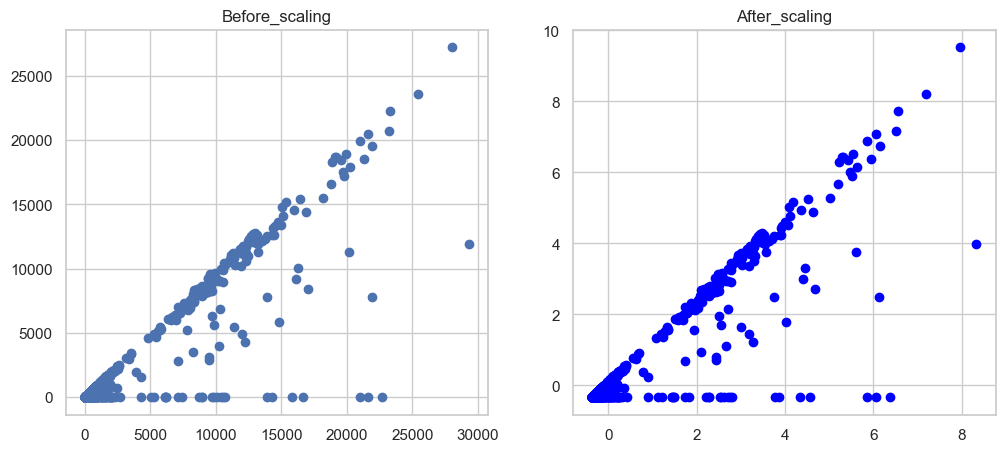

In [27]:
### Visualisation before and after scaling

plt.close('all')

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['billed_amount'], X_train['approved_amount'])
ax1.set_title("Before_scaling")
ax2.scatter(X_train_scaled_df['billed_amount'], X_train_scaled_df['approved_amount'], color='blue')
ax2.set_title("After_scaling")
plt.show()

### Difference in distribution plots

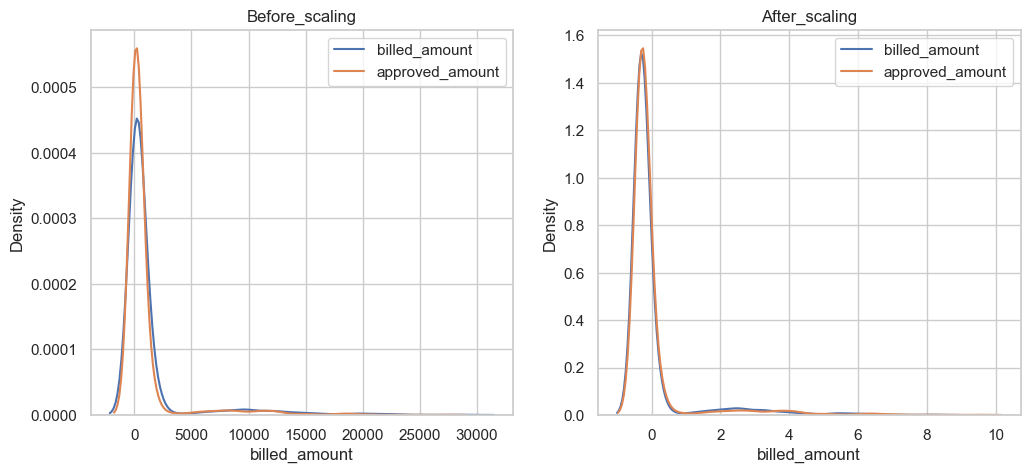

In [28]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Before_scaling")
sns.kdeplot(X_train['billed_amount'], ax=ax1, label='billed_amount')
sns.kdeplot(X_train['approved_amount'], ax=ax1, label='approved_amount')
ax1.legend()

ax2.set_title("After_scaling")
sns.kdeplot(X_train_scaled_df['billed_amount'], ax=ax2, label='billed_amount')
sns.kdeplot(X_train_scaled_df['approved_amount'], ax=ax2, label='approved_amount')
ax2.legend()
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [32]:
lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [33]:
Y_pred=lr.predict(X_test)
Y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
print("Actual", accuracy_score(Y_test, Y_pred))
print("Scaled", accuracy_score(Y_test, Y_pred_scaled))

Actual 0.14492753623188406
Scaled 0.14492753623188406


In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
DtC=DecisionTreeClassifier()
DtC_scaled=DecisionTreeClassifier()

In [38]:
DtC.fit(X_train, Y_train)
DtC_scaled.fit(X_train_scaled, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [39]:
Y_pred=DtC.predict(X_test)
Y_pred_scaled=DtC_scaled.predict(X_test_scaled)


In [40]:
print("Actual", accuracy_score(Y_test, Y_pred))
print("Scaled", accuracy_score(Y_test, Y_pred_scaled))

Actual 0.16485507246376813
Scaled 0.15942028985507245


### Effect of outlier

In [41]:
###  lets add some outlier data

P_I2 = pd.concat([P_I, pd.DataFrame({'billed_amount':[50000,80000], 'approved_amount':[90000,600000], 'payer':['Aetna', 'Medicaid']})], ignore_index=True)
P_I2.tail(5)

,claim_id,patient_id,claim_date,diagnosis_code,diagnosis_description,claim_type,provider_npi,billed_amount,claim_status,approved_amount,payer
2757,CLM502996,PT100009,2024-11-07,E11.9,Type 2 Diabetes without complications,Emergency Room,1.000000e+09,327.97,Approved,283.83,Medicaid
2758,CLM502997,PT101150,2025-08-16,E11.9,Type 2 Diabetes without complications,Prescription,1.000000e+09,50.27,Approved,49.72,Medicare
2759,CLM502998,PT100612,2023-03-23,E11.9,Type 2 Diabetes without complications,Outpatient Visit,1.000000e+09,237.47,Approved,232.88,Aetna
2760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50000.00,NaN,90000.00,Aetna
2761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80000.00,NaN,600000.00,Medicaid


In [43]:
P_I2.shape

(2762, 11)

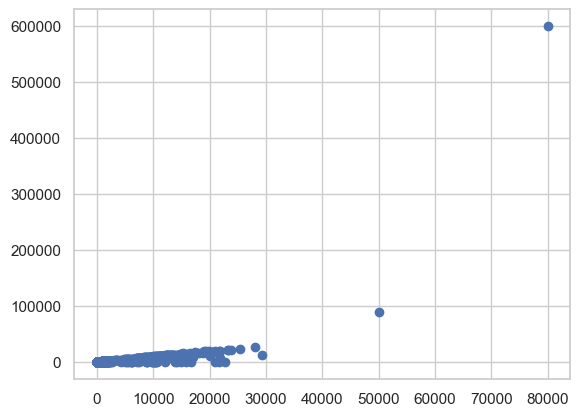

In [44]:
plt.scatter(P_I2['billed_amount'], P_I2['approved_amount'])

In [45]:
X2=P_I2[['billed_amount', 'approved_amount']]
X2


,billed_amount,approved_amount
0,59.13,53.95
1,67.59,67.22
2,2557.82,2188.41
3,7707.24,6572.36
4,43.31,42.64
...,...,...
2757,327.97,283.83
2758,50.27,49.72
2759,237.47,232.88
2760,50000.00,90000.00


In [46]:
payer_map= {'Aetna':1, 'Medicare':2, 'Medicaid':3, 'Cigna':4, 'UnitedHealthcare':5, 'BlueCross BlueShield':6}
Y2=P_I2['payer'].map(payer_map).astype(int)
Y2

0       1
1       2
2       3
3       4
4       5
       ..
2757    3
2758    2
2759    1
2760    1
2761    3
Name: payer, Length: 2762, dtype: int64

In [47]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, Y2_train, Y2_test= train_test_split(X2,Y2, test_size=0.2)
X2_train, X2_test, Y2_train, Y2_test

(      billed_amount  approved_amount
 1970          54.42            50.98
 880           72.77             0.00
 2378        1925.90             0.00
 2401       23220.02         20680.82
 2275       10928.83          5059.27
 ...             ...              ...
 2407          66.61            60.08
 808          156.86             0.00
 1764         484.17           432.53
 581           48.74            45.84
 1140         423.79           419.43
 
 [2209 rows x 2 columns],
       billed_amount  approved_amount
 2475         978.29           968.24
 781          105.59            72.36
 328          122.50           109.91
 297          287.13           253.03
 1622          88.71            37.09
 ...             ...              ...
 1247          40.75             0.00
 2           2557.82          2188.41
 429           57.83            50.63
 1069         104.75           101.40
 290           97.00            92.62
 
 [553 rows x 2 columns],
 1970    2
 880     3
 2378    6


In [48]:
from sklearn.preprocessing import StandardScaler

# fit the scaler to the train set, it will learn the parameters

scaler=StandardScaler()
scaler.fit(X2_train)

# transform train and test sets
X2_train_scaled=scaler.transform(X2_train)
X2_test_scaled=scaler.transform(X2_test)

In [49]:
X2_train_scaled_df = pd.DataFrame(X2_train_scaled, columns=X2_train.columns)
np.round(X2_train_scaled_df.describe(), 1)

,billed_amount,approved_amount
count,2209.0,2209.0
mean,0.0,0.0
std,1.0,1.0
min,-0.3,-0.1
25%,-0.3,-0.1
50%,-0.3,-0.1
75%,-0.2,-0.1
max,20.3,45.5


In [50]:
scaler.mean_

array([1290.50485287, 1227.97962879])

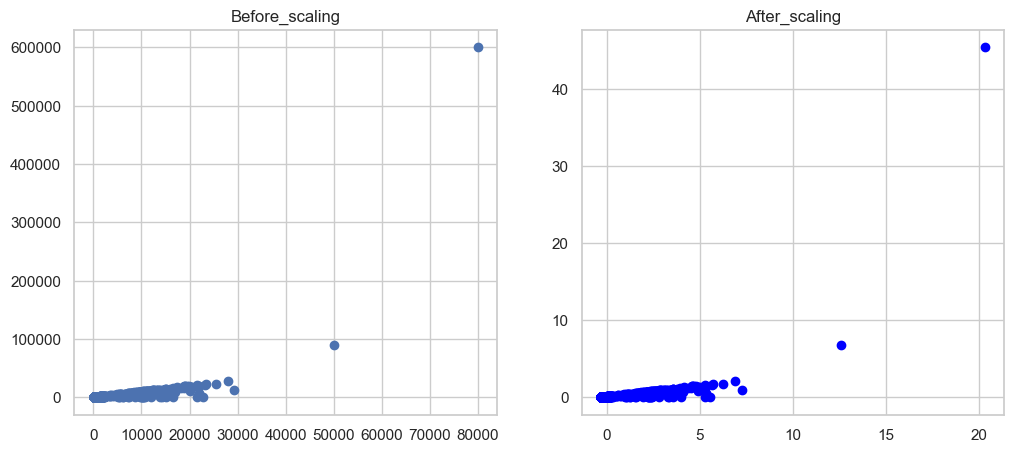

In [51]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X2_train['billed_amount'], X2_train['approved_amount'])
ax1.set_title("Before_scaling")
ax2.scatter(X2_train_scaled_df['billed_amount'], X2_train_scaled_df['approved_amount'], color='blue')
ax2.set_title("After_scaling")
plt.show()

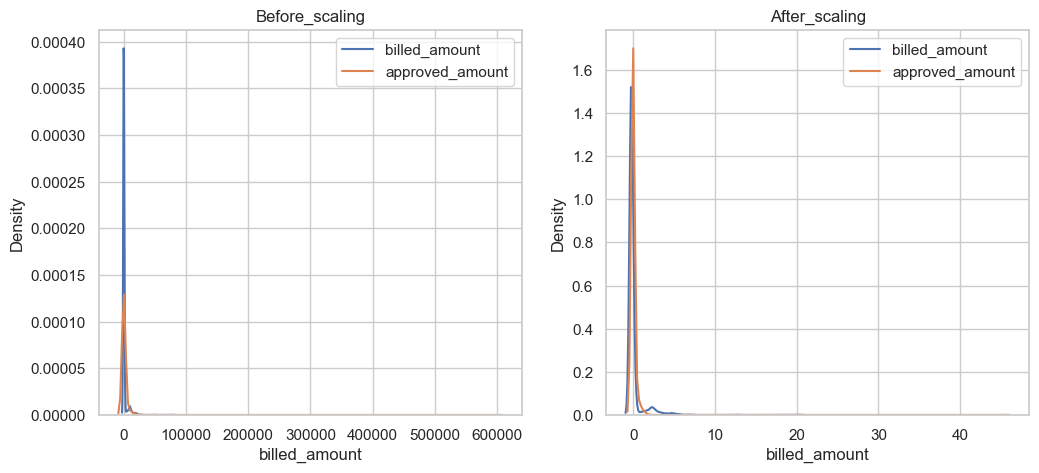

In [52]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))


ax1.set_title("Before_scaling")
sns.kdeplot(X2_train['billed_amount'], ax=ax1, label='billed_amount')
sns.kdeplot(X2_train['approved_amount'], ax=ax1, label='approved_amount')
ax1.legend()

ax2.set_title("After_scaling")
sns.kdeplot(X2_train_scaled_df['billed_amount'], ax=ax2, label='billed_amount')
sns.kdeplot(X2_train_scaled_df['approved_amount'], ax=ax2, label='approved_amount')
ax2.legend()
plt.show()

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()
lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)

C:\Users\lands\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [55]:
Y2_pred=lr.predict(X2_test)
Y2_pred_scaled=lr_scaled.predict(X2_test_scaled)

In [56]:
from sklearn.metrics import accuracy_score


In [57]:
print("Actual", accuracy_score(Y2_test, Y2_pred))
print("Scaled", accuracy_score(Y2_test, Y2_pred_scaled))

Actual 0.17721518987341772
Scaled 0.17540687160940324
